<a href="https://colab.research.google.com/github/yogeshne9i/Stock_Price_Analysis_Major/blob/main/01_Data_Preprocessing_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
###Stock Price Forecasting and Financial Market Analysis using Machine Learning & Time Series Models

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
df = pd.read_csv("US_Stock_Data.csv")
df.head()

,Unnamed: 0,Date,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Price,Bitcoin_Vol.,...,Berkshire_Price,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Price,Gold_Vol.
0,0,2/2/2024,2.079,NaN,72.28,NaN,3.8215,NaN,"43,194.70",42650,...,"5,89,498",10580,564.64,4030000,171.81,117220000,474.99,84710000,"2,053.70",NaN
1,1,1/2/2024,2.050,161340.0,73.82,577940.0,3.8535,NaN,"43,081.40",47690,...,"5,81,600",9780,567.51,3150000,159.28,66360000,394.78,25140000,"2,071.10",260920.0
2,2,31-01-2024,2.100,142860.0,75.85,344490.0,3.9060,NaN,"42,580.50",56480,...,"5,78,020",9720,564.11,4830000,155.20,49690000,390.14,20010000,"2,067.40",238370.0
3,3,30-01-2024,2.077,139750.0,77.82,347240.0,3.9110,NaN,"42,946.20",55130,...,"5,84,680",9750,562.85,6120000,159.00,42290000,400.06,18610000,"2,050.90",214590.0
4,4,29-01-2024,2.490,3590.0,76.78,331930.0,3.8790,NaN,"43,299.80",45230,...,"5,78,800",13850,575.79,6880000,161.26,42840000,401.02,17790000,"2,034.90",1780.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1013 entries, 0 to 1012
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1013 non-null   int64  
 1   Date               1013 non-null   object 
 2   Natural_Gas_Price  1013 non-null   float64
 3   Natural_Gas_Vol.   1009 non-null   float64
 4   Crude_oil_Price    1013 non-null   float64
 5   Crude_oil_Vol.     990 non-null    float64
 6   Copper_Price       1013 non-null   float64
 7   Copper_Vol.        976 non-null    float64
 8   Bitcoin_Price      1013 non-null   object 
 9   Bitcoin_Vol.       1013 non-null   int64  
 10  Platinum_Price     1013 non-null   object 
 11  Platinum_Vol.      636 non-null    float64
 12  Ethereum_Price     1013 non-null   object 
 13  Ethereum_Vol.      1013 non-null   int64  
 14  S&P_500_Price      1013 non-null   object 
 15  Nasdaq_100_Price   1013 non-null   object 
 16  Nasdaq_100_Vol.    1012 

In [ ]:
df.describe()

,Unnamed: 0,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Vol.,Platinum_Vol.,Ethereum_Vol.,...,Nvidia_Price,Nvidia_Vol.,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Vol.
count,1013.000000,1013.000000,1009.000000,1013.000000,9.900000e+02,1013.000000,976.000000,1.013000e+03,636.000000,1.013000e+03,...,1013.000000,1.013000e+03,1013.000000,1013.000000,1.013000e+03,1013.000000,1.013000e+03,1013.000000,1.013000e+03,1011.000000
mean,506.000000,3.726667,129091.932607,69.853475,3.571739e+05,3.726843,37606.752049,4.924137e+07,9082.515723,1.958002e+07,...,219.738065,4.629821e+07,2918.400790,422.035479,7.012043e+06,137.426209,7.452566e+07,252.151046,2.504895e+07,189442.393670
std,292.572213,1.943030,64035.426727,21.986697,1.864309e+05,0.646524,39192.315092,3.251389e+08,8876.538587,1.469409e+08,...,128.668703,1.878815e+07,2715.637488,119.765870,6.788094e+06,27.321896,3.376809e+07,72.949246,1.635122e+07,104007.872337
min,0.000000,1.482000,1200.000000,-37.630000,1.702000e+04,2.100500,10.000000,2.600000e+02,0.000000,7.518000e+04,...,49.100000,9.790000e+06,120.000000,166.370000,1.140000e+06,81.820000,2.162000e+07,88.910000,5.470000e+06,0.000000
25%,253.000000,2.447000,88680.000000,54.760000,2.751800e+05,3.408000,380.000000,7.142000e+04,1120.000000,5.272300e+05,...,131.980000,3.348000e+07,760.000000,338.630000,3.780000e+06,114.770000,5.192000e+07,195.210000,1.612000e+07,142985.000000
50%,506.000000,2.880000,125980.000000,72.910000,3.450350e+05,3.800500,31635.000000,1.288800e+05,6070.000000,9.665800e+05,...,179.130000,4.368000e+07,2040.000000,431.600000,5.380000e+06,142.300000,6.515000e+07,262.010000,2.107000e+07,181200.000000
75%,759.000000,4.805000,164810.000000,82.810000,4.269225e+05,4.251500,70982.500000,3.860000e+05,15287.500000,3.670000e+06,...,272.470000,5.640000e+07,4090.000000,509.640000,7.890000e+06,161.060000,8.683000e+07,313.190000,2.903000e+07,231500.000000
max,1012.000000,9.647000,381970.000000,123.700000,1.770000e+06,4.937500,176040.000000,4.470000e+09,42830.000000,1.790000e+09,...,661.600000,1.534600e+08,13850.000000,691.690000,1.333900e+08,186.570000,3.113500e+08,474.990000,2.304100e+08,813410.000000


In [ ]:
#Data Cleaning
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df['Date'] = pd.to_datetime(df['Date'])

# Sort by Date
df = df.sort_values('Date').reset_index(drop=True)

df.isnull().sum()

,0
Date,0
Natural_Gas_Price,0
Natural_Gas_Vol.,4
Crude_oil_Price,0
Crude_oil_Vol.,23
Copper_Price,0
Copper_Vol.,37
Bitcoin_Price,0
Bitcoin_Vol.,0
Platinum_Price,0


In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())


In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [ ]:
# Daily return
df['Netflix_Return'] = df['Netflix_Price'].pct_change()

# Moving averages
df['MA_7'] = df['Netflix_Price'].rolling(7).mean()
df['MA_14'] = df['Netflix_Price'].rolling(14).mean()

# Volatility
df['Volatility'] = df['Netflix_Return'].rolling(7).std()

df.dropna(inplace=True)
df.head()


,Date,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Price,Bitcoin_Vol.,Platinum_Price,...,Meta_Vol.,Gold_Price,Gold_Vol.,Year,Month,Day,Netflix_Return,MA_7,MA_14,Volatility
13,2020-01-22,1.905,240000.0,56.74,620120.0,2.7650,71190.0,"8,678.50",509060,"1,022.60",...,12210000,"1,556.70",286080.0,2020,1,22,-0.035817,337.011429,334.667143,0.019180
14,2020-01-23,1.926,179790.0,55.59,704000.0,2.7260,88850.0,"8,405.10",722670,"1,009.05",...,11200000,"1,565.40",361030.0,2020,1,23,0.072393,338.537143,336.080714,0.032636
15,2020-01-24,1.893,142190.0,54.19,586200.0,2.6840,72570.0,"8,439.90",617020,"1,010.25",...,11910000,"1,571.90",427140.0,2020,1,24,0.010183,340.604286,338.027857,0.032585
16,2020-01-27,1.902,72170.0,53.14,712880.0,2.5965,118990.0,"8,866.60",706450,991.3,...,13810000,"1,577.40",398060.0,2020,1,27,-0.029109,341.148571,338.531429,0.035298
17,2020-01-28,1.934,59300.0,53.48,633960.0,2.5795,100470.0,"9,377.30",954200,990.7,...,13410000,"1,569.80",378010.0,2020,1,28,0.016449,342.562857,339.800714,0.035646


In [ ]:
#Exploratory Data Analysis(EDA)

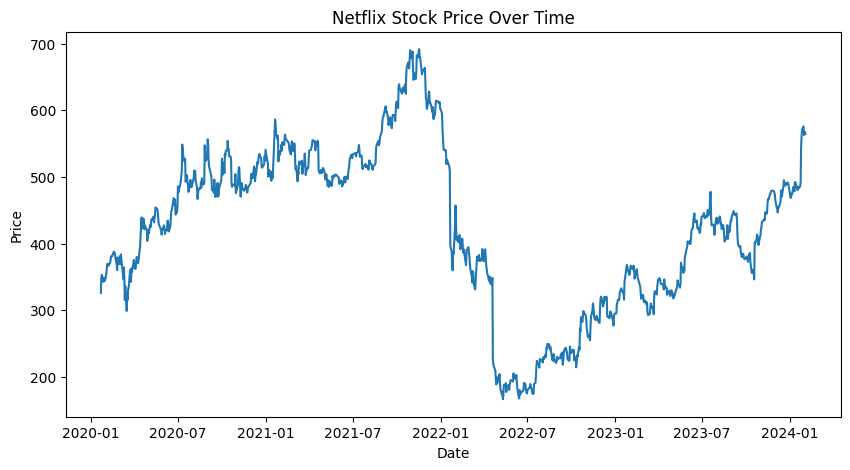

In [ ]:
#Netflix Price Trend
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Netflix_Price'])
plt.title("Netflix Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


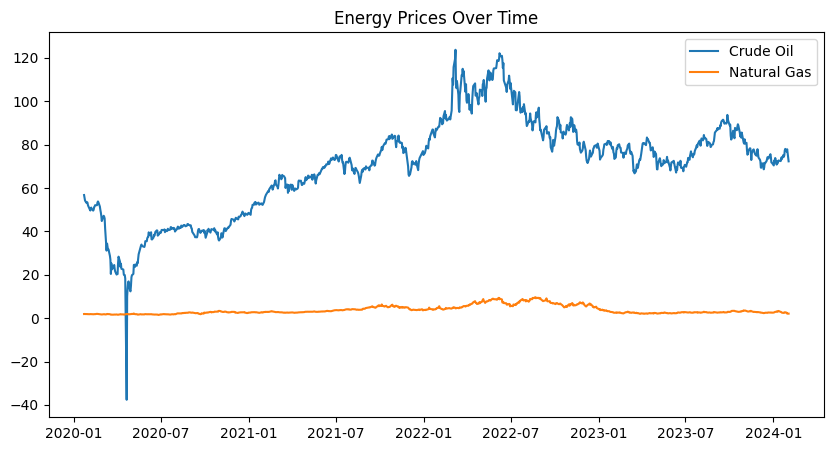

In [ ]:
#Energy Prices Impact
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Crude_oil_Price'], label='Crude Oil')
plt.plot(df['Date'], df['Natural_Gas_Price'], label='Natural Gas')
plt.legend()
plt.title("Energy Prices Over Time")
plt.show()


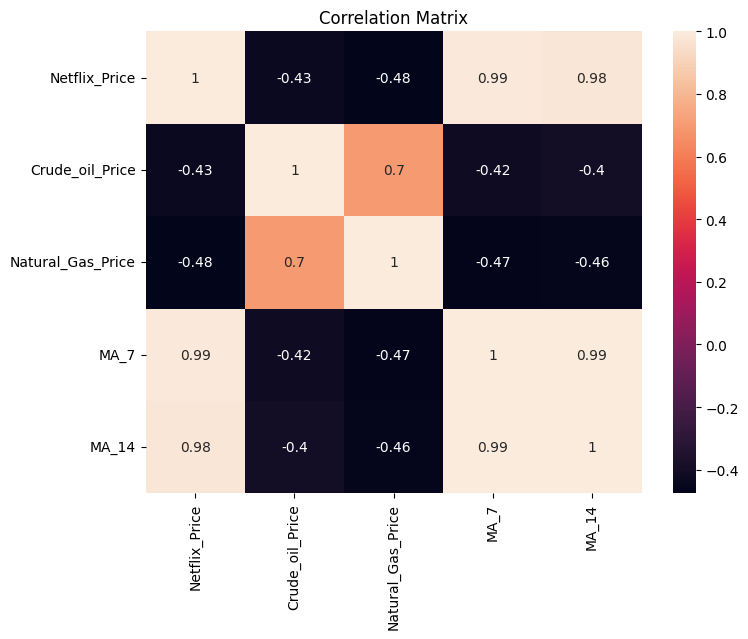

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['Netflix_Price','Crude_oil_Price','Natural_Gas_Price','MA_7','MA_14']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()
